In [7]:
%load_ext autoreload
%autoreload 2

import random
import pickle
import json

import pandas as pd
pd.options.display.max_columns = 100

# Подргужаем модули
import all_blocks
from merge_contracts import ContractsMerger
from generate_test import generate_preds
from get_distribution_utils import get_disrib_sums, cost_columns_to_datetime
from forecasting import load_data, make_predict_timeseries

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Подгружаем и обрабатываем входные данные

In [8]:
pays_df1 = pd.read_excel("data/Счета на оплату 3800-2023.XLSX")
pays_df2 = pd.read_excel("data/Счета на оплату 4200-4000-3800-2024.XLSX")
pays_df3 = pd.read_excel("data/Счета на оплату 5400-2023.XLSX")
pays_df4 = pd.read_excel("data/Счета на оплату 5400-2024.XLSX")
pays_df5 = pd.read_excel("data/Счета на оплату 5500-2023.XLSX")

In [9]:
pays_df = pd.concat([pays_df1, pays_df2, pays_df3, pays_df4, pays_df5], axis=0)

In [10]:
merger_df = pd.read_excel("data/Связь договор - здания.XLSX")
main_costs_df = pd.read_excel("data/Основные средства.XLSX")
squares = pd.read_excel("data/Площади зданий.XLSX")
serv_codes = pd.read_excel("data/Коды услуг.XLSX")

In [11]:
# добавляем фичи чтобы показать что система поддерживает новые драйверы
# в случае их появления в исходной таблице
main_costs_df["тест_фича_нум"] = [random.randint(0, 100) for i in range(len(main_costs_df))]
main_costs_df["тест_фича_бул"] = [random.randint(0, 1) for i in range(len(main_costs_df))]
main_costs_df["тест_фича_дата"] = ["19.04.2006"] * len(main_costs_df)

In [12]:
merger = ContractsMerger(pays_df, merger_df, main_costs_df, squares, serv_codes)

E:\DIR_python_projects\ledaer_digital_transformation_24\zakupai\services\api\ml\lib\merge_contracts.py:78: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.needed_pays_df["time"] = self.needed_pays_df["Год"].map(lambda x: datetime(year=x, month=1, day=1))


In [13]:
import time

t = time.time()
res, features = merger.start_merging()
print("Время мерджинга файлов и генерации фич:", time.time() - t)

Время мерджинга файлов и генерации фич: 76.67715167999268


In [14]:
# сохраняем результат с 1 страницы загрузки данных
res.to_csv("res_datetimes.csv")
with open("features.pkl", "wb") as f:
    pickle.dump(features, f)

## Подгружаем граф, запускаем распределение

In [15]:
features = pickle.load(open("features.pkl", "rb"))
res = pd.read_csv("res_datetimes.csv", index_col=0)

C:\Users\843E~1\AppData\Local\Temp/ipykernel_26140/930177580.py:2: DtypeWarning: Columns (22) have mixed types. Specify dtype option on import or set low_memory=False.
  res = pd.read_csv("res_datetimes.csv", index_col=0)


In [16]:
numeric_features = [i[0] for i in features if i[2] != "date"]
date_features = [i[0] for i in features if i[2] == "date"]

res = cost_columns_to_datetime(res, date_features)

In [17]:
res_by_prime = res.groupby("prime")
raw_graph = json.load(open("graphs/graph (6).json", "r"))

In [18]:
all_blocks.init_graph(raw_graph, features)

In [19]:
unique_primes = res["prime"].unique()
distrib_sums = get_disrib_sums(res_by_prime, res["prime"].unique(), numeric_features)

100%|██████████| 4793/4793 [00:10<00:00, 453.37it/s]


In [20]:
preds = generate_preds(pays_df, serv_codes, res, distrib_sums)

100%|██████████| 4793/4793 [00:09<00:00, 488.78it/s]


In [21]:
preds.to_csv("Результат_распределенные_счета.csv")  # мы получили готовое распределени

In [22]:
# посмотрим на результат
# также предсказан счет главной книги
preds.head(5)

,Компания,Год счета,Номер счета,Позиция счета,Номер позиции распределения,Дата отражения в учетной системе,ID договора,Услуга,Класс услуги,Здание,Класс ОС,ID основного средства,"Признак ""Использование в основной деятельности""","Признак ""Способ использования""",Площадь ОС,Сумма распределения,Счет главной книги,ID услуги
0,3800,2023,5006170938,1,0,2023-01-16 00:00:00,ДПН 3800/74661,800003299,S001,ЗДН 3800/1/265,60401018,38006040010385571,1,1,1.0,540679.38,7048208010,S001
1,3800,2023,5006170938,1,1,2023-01-16 00:00:00,ДПН 3800/74661,800003299,S001,ЗДН 3800/1/265,60401018,38006040010385572,0,1,1.1,594747.32,7048208010,S001
2,3800,2023,5006170938,1,2,2023-01-16 00:00:00,ДПН 3800/74661,800003299,S001,ЗДН 3800/1/1538,60804001,38006080400345271,0,0,0.0,0.00,7048208010,S001
58919,5400,2023,5006176256,1,0,2023-01-18 00:00:00,ДПН 5400/143136,800002266,S036,ЗДН 5400/1/7432,60804001,54006080400468090,1,0,150.9,69554.00,7048414960,S036
58920,5400,2023,5006176256,2,0,2023-01-18 00:00:00,ДПН 5400/143136,800002266,S036,ЗДН 5400/1/7432,60804001,54006080400468090,1,0,150.9,51552.00,7048414960,S036


## Прогнозирование

100%|██████████| 322/322 [00:00<00:00, 3701.14it/s]


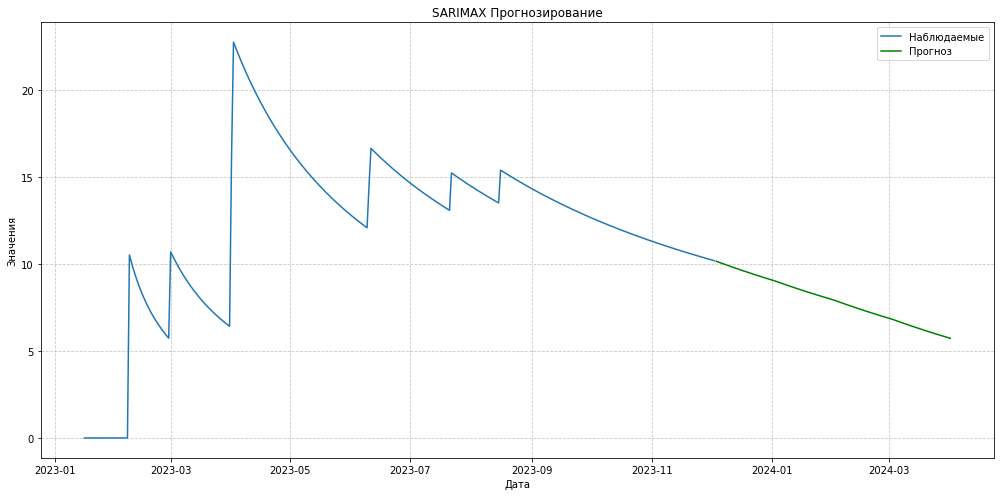

In [23]:
tmp = make_predict_timeseries(preds, check_ID=55006040032948470, forecast_period=120)